# PyTorch: Autoencoder convolucional Fashion-MNIST

## Refs.

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb

## **Ejercicio 1)** Importando librerías

**0)** De ser necesario, **instale PyTorch** escribiendo

    !pip3 install torch torchvision torchaudio torchviz

**1)** Importe las librerías estandard de Python: `os`, `datetime`, `collections` y `pickle`.

**2)** Importe las siguientes librerías third party de Python: `matplotlib.pyplot`, `numpy`, `scipy`, `sklearn`, `pandas`, `dill` y `json`.

**3)** Importe las librerias necesarias de **PyTorch**: `torch` y `torchvision`.

**4)** Importe la librería: `google.colab`.

In [1]:
# 1.0)
!pip3 install torch torchvision torchaudio torchviz

Defaulting to user installation because normal site-packages is not writeable


In [1]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [2]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json

In [3]:
# 1.3)
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

In [6]:
# 1.4)
#import google.colab
# from google.colab import files

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando dispositivo:", device)

Usando dispositivo: cpu


## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

In [8]:
# 2.1)
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

# Download and load the training data
train_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

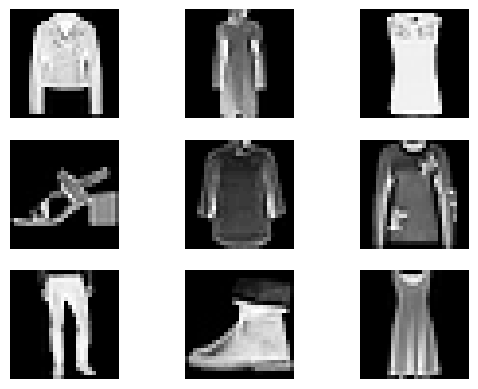

In [9]:
# 2.2)
figure = plt.figure()
cols,rows = 3,3
for i in range(1,cols*rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # Los números aleatorios tambien se pueden generar desde pytorch. Util para trabajar en la GPU.
    image,label = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    #plt.title(labels_names[label])
    plt.axis("off")
    plt.imshow(image.squeeze(),cmap="Greys_r")
plt.show()

## Ejercicio 3) Creando un `DataSet` personalizado.

**1)** Con el fin de implementar un autoencoder, cree una clase derivada de la clase `DataSet` (llámela, por ejemplo `CustomDataset`) que, en vez de retornal el label asociado a cada imagen de `FashionMNIST`, retorne la imagen misma.

**2)** Utilice dicha clase para transformar los conjuntos de entrenamiento y testeo de `FashionMNIST` pensados para clasificación, a correspondientes conjuntos pensados para entrenar un autoencoder.
Para ello, defina una clase `CustomDataset` que deriva de la clase `Dataset`, cuyo método `__getitem__(self,i)` retorne el pair `input,output` donde tanto `input` cómo `output` son iguales a la $i$-ésima imagen del dataset.

In [10]:
# 3.1)
# Creamos una subclase de la clase Dataset que nos sirva para generar lotes de ejemplos que puedan usarse para entrenar un autoencoder
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset=dataset
    # Redefinimos el método .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefinimos el método .__getitem__()
    def __getitem__(self,i):
        image,label=self.dataset[i]
        input  = image
        output = image #torch.flatten(image) # retornamos la imagen como salida
        return input,output

In [11]:
# 3.2)
# Convertimos FashionMNIST Dataset a CustomDataset
train_set = CustomDataset(train_set_orig)
valid_set = CustomDataset(valid_set_orig)

## Ejercicio 4) Red Neuronal Autoencoder Convolucional

**1)** Defina y cree una red neuronal *autoencoder convolucional* constituida por las siguientes capas:


1. Capa convolucional 2D (encoder) compuesta por:

  * Una capa `Conv2d` (ver [documentación](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)) que mapea una entrada con $1$ canal y dimensiones $(28,28)$ a una salida con $16$ canales y dimensiones $(26,26)$.
    Utilice un kernel de dimensiones $(3,3)$ y el resto de los parámetros en sus valores por defecto.
  * Una capa `ReLU`.
  * Una capa `MaxPool2d` con un kernel de dimensiones $(2,2)$, de modo que la salida resultante tenga dimensiones $(16,13,13)$.
  * Una capa `Dropout` con probabilidad $p$.

2. Capa lineal (cuello de botella o “bottleneck”) compuesta por:

  * Una capa `Flatten` que transforma una entrada de dimensiones $(16,13,13)$ en un vector de dimensión $16\times 13\times 13 = 2704$.
  * Una capa `Linear` que mapea el vector de dimensión $2704$ a un vector de dimensión $n$ (donde $n$ es un número mucho menor, por ejemplo $n=128$, representando la *codificación comprimida* o *latente*).
  * Una capa `ReLU`.
  * Una capa `Linear` que mapea de nuevo el vector de dimensión $n$ al espacio original de dimensión $2704$.
  * Una capa `ReLU`.

3. Capa convolucional 2D transpuesta (decoder) compuesta por:

  * Una capa `Unflatten` que mapea el vector de dimensión $2704$ a una representación de $16$ canales con dimensiones $(13,13)$.
  * Una capa `ConvTranspose2d` (ver [documentación](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)) que mapea $16$ canales de dimensiones $(13,13)$ a $1$ canal de dimensiones $(28,28)$. Utilice un kernel de dimensiones $(6,6)$, un stride de $(2,2)$, y un padding de $(1,1)$.
  * Una capa `Sigmoid`, para asegurar que las salidas se encuentren en el rango $[0,1]$ (asumiendo que las imágenes originales también fueron normalizadas en dicho rango).

**2)** Grafique, a modo de comparación, algunas imágenes de entrada y sus correspondientes reconstrucciones obtenidas con el modelo **sin entrenar** y con una probabilidad de *dropout* $p=0.2$.

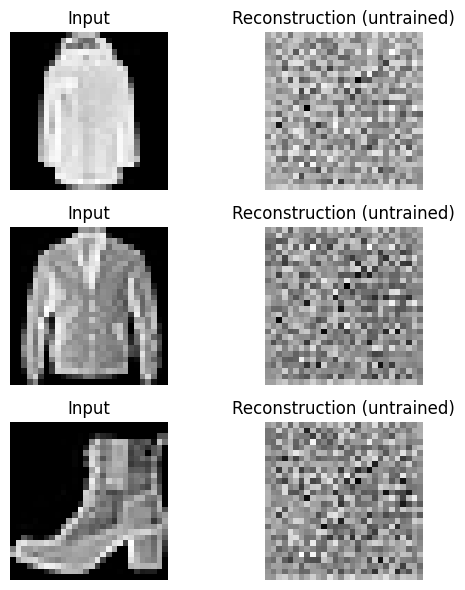

In [12]:
# 4.1
# Autoencoder model (encoder -> bottleneck -> decoder) and untrained reconstructions plot

class ConvAutoencoder(nn.Module):
    def __init__(self, p=0.2, latent_dim=128):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3), # -> (16,26,26). Aplica 16 filtros 3x3 sin padding y stride 1. Resultado (28-3)/1 +1 = 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                              # -> (16,13,13) Reduce 26x26 a 13x13
            nn.Dropout(p)
        )
        # Bottleneck (flatten -> latent -> expand)
        self.flatten = nn.Flatten()                                   # (16*13*13 = 2704)
        self.fc1 = nn.Linear(16*13*13, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 16*13*13)
        self.relu = nn.ReLU()
        self.unflatten = nn.Unflatten(1, (16, 13, 13))
        
        # Decoder (transposed conv to recover 28x28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=16, out_channels=1,
                               kernel_size=6, stride=2, padding=1),   # -> (1,28,28)
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.unflatten(x)
        x = self.decoder(x)
        return x

# Instantiate model (dropout p=0.2) and send to device
model = ConvAutoencoder(p=0.2, latent_dim=128).to(device)
model.eval()

# Selecciona algunos ejemplos del conjunto de entrenamiento (no sobrescribir nombres existentes)
num_examples = 3
sample_idxs = torch.randint(len(train_set), (num_examples,))
samples = [train_set[int(idx)][0] for idx in sample_idxs]  # cada uno es un tensor (1,28,28)

# prepara lote y ejecuta a través del modelo no entrenado (sin grad)
batch = torch.stack(samples, dim=0).to(device)  # shape (num_examples,1,28,28)
with torch.no_grad():
    recon_batch = model(batch)  # outputs in [0,1], shape (num_examples,1,28,28)

# plot entradas vs reconstrucciones (convertir entrada de normalizado [-1,1] -> [0,1])
fig, axes = plt.subplots(num_examples, 2, figsize=(6, 2*num_examples))
for k in range(num_examples):
    inp = batch[k].cpu().squeeze(0)            # normalized in [-1,1]
    inp_disp = (inp + 1.0) / 2.0               # map to [0,1] for display
    recon = recon_batch[k].cpu().squeeze(0)    # already in [0,1]

    ax_inp = axes[k, 0] if num_examples > 1 else axes[0]
    ax_rec = axes[k, 1] if num_examples > 1 else axes[1]

    ax_inp.imshow(inp_disp.numpy(), cmap="Greys_r")
    ax_inp.set_title("Input")
    ax_inp.axis("off")

    ax_rec.imshow(recon.numpy(), cmap="Greys_r")
    ax_rec.set_title("Reconstruction (untrained)")
    ax_rec.axis("off")

plt.tight_layout()
plt.show()


## Ejercicio 5) Entrenando el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de prueba o validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` que estén definidos sobre  el `train_set` (conjunto de entranmiento) y el `valid_set` (conjunto de prueba) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando el **Error Cuadrático Medio**.

**5)** Cree un optimizador con un learning rate igual a $10^{-3}$.
Pruebe con **ADAM**.

**6)** Cree una instancia del modelo con dropout $p=0.2$.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop que itere sobre épocas de entrenamiento y validación, y que guarde en listas correspondientes los siguientes valores del **ECM**:
*  promedios (incorrectos) sobre el conjunto de entrenamiento, calculado **durante** el proceso de entrenamiento sobre la época.
*  promedios (correctos) sobre el conjunto de entrenamiento, calculados **posteriormente** al proceso de entrenamiento sobre la época.
*  promedios (correctos) sobre el conjunto de validación, calculados **posteriormente** al proceso de entrenamiento sobre la época.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso **8)** para graficar en función de las **épocas de entrenamiento** el **ECM** de **entrenamiento** y **validación**, respectivamente.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Grafique, comparativamente, algunas de las imagenes a predecir vs las imagenes predichas por el modelo entrenado.

**12)** Repita para otras elecciones de los hiperparámetros tales como, el optimizador (podría ser el **SGD**), el **learning-rate**, el tamaño de los **batchs**, el **dropout**, **capas convolucionales** y **convolucionales traspuestas** de otros tamaños.
En particular, pruebe eliminando, adecuadamente, la **capa lineal**.
Que valores de estos hiperparámetros considera los más convenientes? Porqué?

In [17]:
import torch
from torch import nn

# crea el modelo tal y como está, o usa ConvAutoencoder modificado
model = ConvAutoencoder(p=0.2, latent_dim=128).to(device)
model.eval()

x = torch.randn(4, 1, 28, 28).to(device)
with torch.no_grad():
    y = model(x)
print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([4, 1, 28, 28])
output shape: torch.Size([4, 1, 28, 28])


Epoch  1 | train_during: 0.024290 | train_after: 0.012748 | valid_after: 0.012841
Epoch  2 | train_during: 0.011730 | train_after: 0.009698 | valid_after: 0.009813
Epoch  3 | train_during: 0.009923 | train_after: 0.008508 | valid_after: 0.008632
Epoch  4 | train_during: 0.009056 | train_after: 0.007837 | valid_after: 0.007967
Epoch  5 | train_during: 0.008566 | train_after: 0.007504 | valid_after: 0.007638
Epoch  6 | train_during: 0.008238 | train_after: 0.007183 | valid_after: 0.007324
Epoch  7 | train_during: 0.008009 | train_after: 0.007023 | valid_after: 0.007167
Epoch  8 | train_during: 0.007827 | train_after: 0.006814 | valid_after: 0.006972
Epoch  9 | train_during: 0.007684 | train_after: 0.006703 | valid_after: 0.006864
Epoch 10 | train_during: 0.007585 | train_after: 0.006620 | valid_after: 0.006780
Epoch 11 | train_during: 0.007478 | train_after: 0.006566 | valid_after: 0.006731
Epoch 12 | train_during: 0.007399 | train_after: 0.006443 | valid_after: 0.006615
Epoch 13 | train

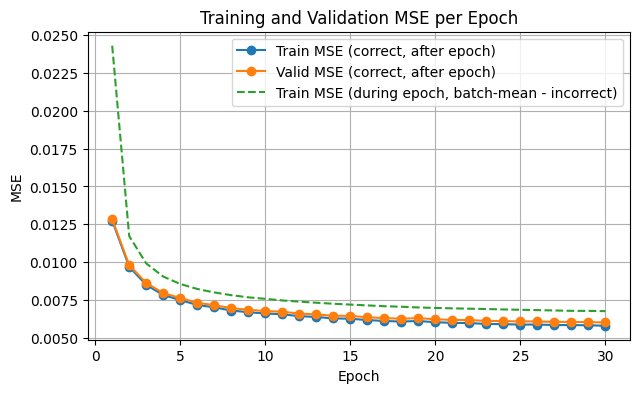

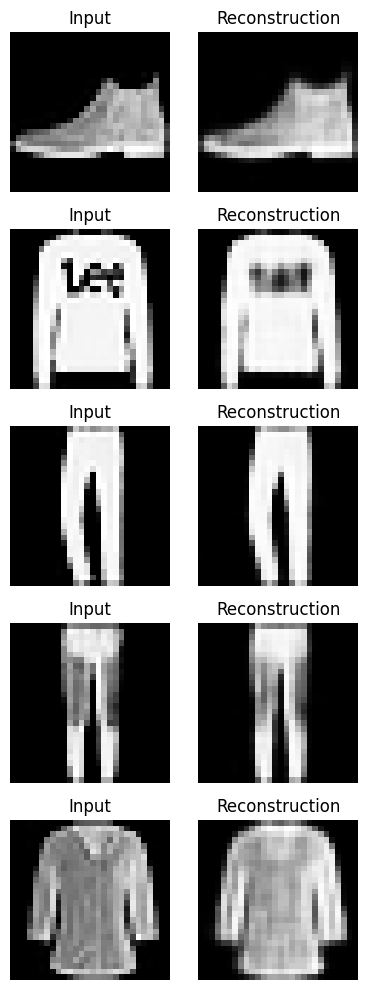

In [19]:
# 5.1) Entrenando y validando: bucles, dataloaders, optimizador, pérdida, ejecución de entrenamiento y gráficos

# 3) DataLoaders
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)

# 4) Loss (MSE) and 5) Optimizer (Adam lr=1e-3)
criterion = nn.MSELoss(reduction='mean')
# 6) Create model instance (dropout p=0.2) and send to device (7)
model = ConvAutoencoder(p=0.2, latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Utility: compute dataset MSE (correct average over all examples)
def compute_dataset_mse(dataloader, model, device):
    model.eval()
    running_loss = 0.0
    total_examples = 0
    with torch.no_grad():
        for xb, yb in dataloader:
            # xb,yb come from CustomDataset: both are image tensors normalized to [-1,1]
            xb = xb.to(device)
            # target must be in same scale as model output (Sigmoid in [0,1]) -> map xb from [-1,1] to [0,1]
            target = (xb + 1.0) / 2.0
            out = model(xb)
            loss = criterion(out, target)
            bs = xb.shape[0]
            running_loss += loss.item() * bs
            total_examples += bs
    return running_loss / total_examples

# 1) Training loop for one epoch (returns list of batch losses encountered during the epoch)
def train_one_epoch(dataloader, model, optimizer, criterion, device):
    model.train()
    batch_losses = []
    for xb, yb in dataloader:
        xb = xb.to(device)                       # input in [-1,1]
        target = (xb + 1.0) / 2.0                # map to [0,1] to match Sigmoid output
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    return batch_losses

# 8-9) Full training/validation loop that stores:
#  - train_avg_during (incorrect average computed from batch losses during training)
#  - train_avg_after  (correct average computed on full train set AFTER training epoch)
#  - valid_avg_after  (correct average computed on full valid set AFTER training epoch)
num_epochs = 30
train_avg_during = []
train_avg_after = []
valid_avg_after = []

for epoch in range(1, num_epochs + 1):
    batch_losses = train_one_epoch(train_loader, model, optimizer, criterion, device)
    # incorrect average over training computed during training (mean of batch losses)
    train_avg_during.append(np.mean(batch_losses))
    # correct averages computed over entire datasets
    train_mse = compute_dataset_mse(train_loader, model, device)
    valid_mse = compute_dataset_mse(valid_loader, model, device)
    train_avg_after.append(train_mse)
    valid_avg_after.append(valid_mse)
    print(f"Epoch {epoch:2d} | train_during: {train_avg_during[-1]:.6f} | train_after: {train_avg_after[-1]:.6f} | valid_after: {valid_avg_after[-1]:.6f}")

# 10) Plot MSE curves
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(7,4))
plt.plot(epochs, train_avg_after, label="Train MSE (correct, after epoch)", marker='o')
plt.plot(epochs, valid_avg_after, label="Valid MSE (correct, after epoch)", marker='o')
plt.plot(epochs, train_avg_during, label="Train MSE (during epoch, batch-mean - incorrect)", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.title("Training and Validation MSE per Epoch")
plt.show()

# 11) Visual comparison: some validation inputs vs reconstructions using the trained model
model.eval()
n_show = 5
# take first batch from valid_loader
xb, _ = next(iter(valid_loader))
xb = xb.to(device)[:n_show]
with torch.no_grad():
    recon = model(xb)

# convert to displayable format
xb_disp = ((xb.cpu().squeeze(1) + 1.0) / 2.0).numpy()     # shape (n_show,28,28) in [0,1]
recon_disp = recon.cpu().squeeze(1).numpy()               # already in [0,1]

fig, axes = plt.subplots(n_show, 2, figsize=(4, 2*n_show))
for i in range(n_show):
    ax_in = axes[i,0]
    ax_out = axes[i,1]
    ax_in.imshow(xb_disp[i], cmap='Greys_r')
    ax_in.set_title("Input")
    ax_in.axis('off')
    ax_out.imshow(recon_disp[i], cmap='Greys_r')
    ax_out.set_title("Reconstruction")
    ax_out.axis('off')
plt.tight_layout()
plt.show()

# NOTE / suggestion for 12):
# - Try fewer/more epochs and observe validation curve to choose optimal epoch (early stopping when val MSE stops decreasing).
# - Try removing bottleneck linear layers and use deeper conv encoder/decoder or change activations.
# - Try SGD vs Adam, different lr (1e-3 good starting), batch sizes (32/100/256), and different dropout rates.
# - The optimal hyperparameters depend on validation MSE and reconstruction quality; use the validation curve above to decide.

Epoch  1 | Train loss: 1.2136 acc: 0.5486 | Valid loss: 0.7676 acc: 0.7292
Epoch  2 | Train loss: 0.8066 acc: 0.7025 | Valid loss: 0.6483 acc: 0.7556
Epoch  3 | Train loss: 0.7211 acc: 0.7342 | Valid loss: 0.6182 acc: 0.7623
Epoch  4 | Train loss: 0.6745 acc: 0.7519 | Valid loss: 0.5708 acc: 0.7798
Epoch  5 | Train loss: 0.6379 acc: 0.7643 | Valid loss: 0.5447 acc: 0.7966
Epoch  6 | Train loss: 0.6043 acc: 0.7786 | Valid loss: 0.5073 acc: 0.8193
Epoch  7 | Train loss: 0.5842 acc: 0.7903 | Valid loss: 0.4872 acc: 0.8217
Epoch  8 | Train loss: 0.5617 acc: 0.7978 | Valid loss: 0.4705 acc: 0.8320
Epoch  9 | Train loss: 0.5424 acc: 0.8050 | Valid loss: 0.4522 acc: 0.8355
Epoch 10 | Train loss: 0.5269 acc: 0.8108 | Valid loss: 0.4387 acc: 0.8438


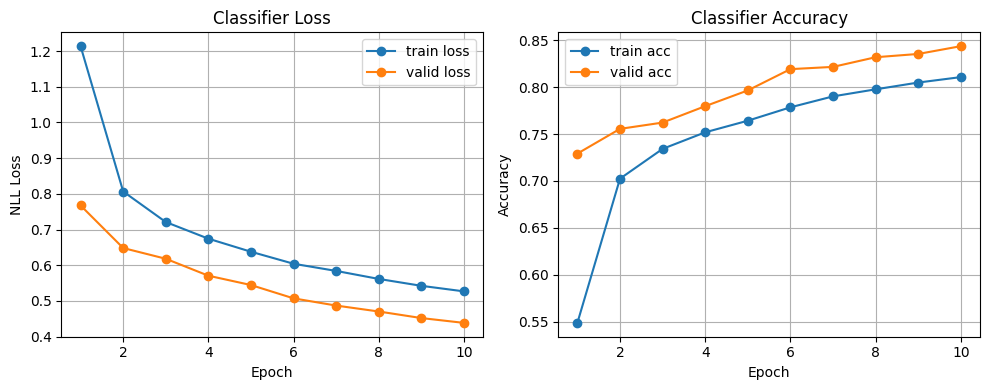

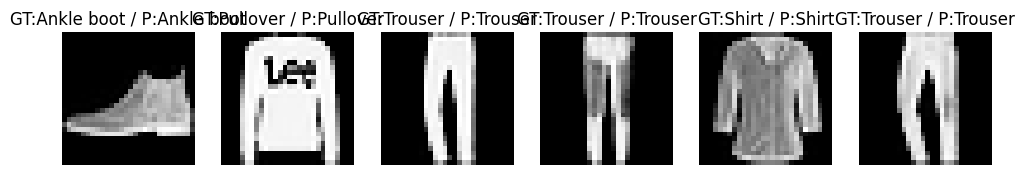

In [ ]:
# Ajustar finamente un clasificador utilizando el codificador de un autoencoder previamente entrenado. (frozen)

# Hyperparameters
batch_size_clf = 100
lr_clf = 1e-3
num_epochs_clf = 10
num_classes = 10

# DataLoaders para clasificación (usar los conjuntos de datos originales de FashionMNIST que incluyen etiquetas)
train_loader_clf = DataLoader(train_set_orig, batch_size=batch_size_clf, shuffle=True)
valid_loader_clf = DataLoader(valid_set_orig, batch_size=batch_size_clf, shuffle=False)

# Define el módulo del clasificador que usa la salida del codificador como entrada
class ClassifierFromEncoder(nn.Module):
    def __init__(self, encoder, num_classes=10, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder  # espera que la entrada esté normalizada como antes ([-1,1])
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
            # use eval mode para deshabilitar el encoder y así desactivar dropout, actualizaciones de batchnorm, etc.
            self.encoder.eval()
        # classifier: multilayer conv -> global pooling -> linear -> LogSoftmax
        self.classifier = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),   # keep spatial dims ~ 13x13
            nn.ReLU(),
            nn.MaxPool2d(2),                                # -> ~6x6
            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),                    # -> (64,1,1)
            nn.Flatten(),                                   # -> (64,)
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
            nn.LogSoftmax(dim=1)                            # use NLLLoss below
        )

    def forward(self, x):
        # ensure encoder run does not compute grads
        with torch.no_grad():
            features = self.encoder(x)   # shape (B,16,13,13)
        out = self.classifier(features)
        return out

# Instantiate classifier model and send to device
clf_model = ClassifierFromEncoder(model.encoder, num_classes=num_classes, freeze_encoder=True).to(device)

# Loss and optimizer (only classifier parameters)
criterion_clf = nn.NLLLoss()
optimizer_clf = optim.Adam(filter(lambda p: p.requires_grad, clf_model.parameters()), lr=lr_clf)

# Training / evaluation loops
def train_epoch_clf(dataloader, model, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb = xb.to(device)   # images normalized [-1,1], encoder expects that
        yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)      # logits after LogSoftmax
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        running_loss += loss.item() * bs
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += bs
    return running_loss / total, correct / total

def eval_epoch_clf(dataloader, model, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            bs = xb.size(0)
            running_loss += loss.item() * bs
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += bs
    return running_loss / total, correct / total

# Training loop with tracking
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
plt.xlabel('Epoch'); plt.ylabel('NLL Loss'); plt.legend(); plt.grid(True)
plt.title('
for epoch in range(1, num_epochs_clf + 1):
    train_loss, train_acc = train_epoch_clf(train_loader_clf, clf_model, optimizer_clf, criterion_clf, device)
    valid_loss, valid_acc = eval_epoch_clf(valid_loader_clf, clf_model, criterion_clf, device)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Valid loss: {valid_loss:.4f} acc: {valid_acc:.4f}")

# Plot losses and accuracies
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1,num_epochs_clf+1), train_losses, label='train loss', marker='o')
plt.plot(range(1,num_epochs_clf+1), valid_losses, label='valid loss', marker='o')
Classifier Loss')

plt.subplot(1,2,2)
plt.plot(range(1,num_epochs_clf+1), train_accuracies, label='train acc', marker='o')
plt.plot(range(1,num_epochs_clf+1), valid_accuracies, label='valid acc', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.title('Classifier Accuracy')

plt.tight_layout()
plt.show()

# Visual check: some validation images and predicted labels
clf_model.eval()
label_names = train_set_orig.classes if hasattr(train_set_orig, 'classes') else list(map(str, range(10)))
xb_vis, yb_vis = next(iter(valid_loader_clf))
n_vis = min(6, xb_vis.size(0))
xb_vis = xb_vis[:n_vis].to(device)
with torch.no_grad():
    out_vis = clf_model(xb_vis)
preds_vis = out_vis.argmax(dim=1).cpu().numpy()
xb_disp_vis = ((xb_vis.cpu().squeeze(1) + 1.0) / 2.0).numpy()

fig, axes = plt.subplots(1, n_vis, figsize=(2*n_vis,2))
for i in range(n_vis):
    axes[i].imshow(xb_disp_vis[i], cmap='Greys_r')
    axes[i].set_title(f"GT:{label_names[int(yb_vis[i])]} / P:{label_names[int(preds_vis[i])]}")
    axes[i].axis('off')
plt.show()

## Diferentes experimentos, a ver que pasa con esto
### Autoencoder convolucional profundo

In [33]:
from typing import List, Tuple, Dict
from torchvision import datasets, transforms
import torch.nn.functional as F

# Experimentos E1..E5: construcción flexible de autoencoders convolucionales y ejecución rápida (1 epoch)
# Requiere: imports, device, train_set, valid_set, compute_dataset_mse están definidos previamente en el notebook.

import torch.nn as nn
import torch.optim as optim

class FlexibleConvAutoencoder(nn.Module):
    def __init__(self,
                 input_channels: int = 1,
                 num_layers: int = 3,
                 base_channels: int = 32,
                 kernel_size: int = 3,
                 stride: int = 2,
                 dropout: float = 0.1,
                 latent_channels: int = 64):
        super().__init__()
        self.input_channels = input_channels
        self.num_layers = num_layers
        self.base_channels = base_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.dropout = dropout
        self.latent_channels = latent_channels



        # Encoder: progressive increase of channels until latent_channels on the last layer
        enc_layers = []
        in_ch = input_channels
        for i in range(num_layers):
            # compute out channels: grow geometrically but ensure last equals latent_channels
            if i == num_layers - 1:
                out_ch = latent_channels
            else:
                out_ch = base_channels * (2 ** i)
            enc_layers.append(
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=(kernel_size-1)//2)
            )
            enc_layers.append(nn.ReLU(inplace=True))
            enc_layers.append(nn.Dropout(p=dropout))
            in_ch = out_ch
        self.encoder = nn.Sequential(*enc_layers)





        # Decoder: mirror encoder
        dec_layers = []
        for i in range(num_layers):
            if i == num_layers - 1:
                out_ch = input_channels
            else:
                # mirror channel progression
                # compute corresponding encoder channel from the end
                idx = num_layers - 2 - i
                out_ch = base_channels * (2 ** max(idx, 0))
            dec_layers.append(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride,
                                   padding=(kernel_size-1)//2, output_padding=(stride-1))
            )
            # Last layer -> Sigmoid to map to [0,1], otherwise ReLU
            if i == num_layers - 1:
                dec_layers.append(nn.Sigmoid())
            else:
                dec_layers.append(nn.ReLU(inplace=True))
                dec_layers.append(nn.Dropout(p=dropout))
            in_ch = out_ch
        self.decoder = nn.Sequential(*dec_layers)




    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        # Ensure output spatial size matches input (robust to rounding differences from Conv/ConvTranspose)
        if out.shape[2:] != x.shape[2:]:
            # Resize output to match input height/width
            # Use bilinear for single/multi-channel images; fallback to nearest if spatial size is 1
            if x.shape[2] > 1 and x.shape[3] > 1:
                out = F.interpolate(out, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
            else:
                out = F.interpolate(out, size=(x.shape[2], x.shape[3]), mode='nearest')
        return out




# Quick train / eval helpers (reuse criterion from notebook if present)
criterion = nn.MSELoss(reduction='mean')



def train_one_epoch_quick(dataloader, model, optimizer, device):
    model.train()
    running = 0.0
    total = 0
    for xb, _ in dataloader:
        xb = xb.to(device)
        target = (xb + 1.0) / 2.0
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        running += loss.item() * bs
        total += bs
    return running / total

def eval_quick(dataloader, model, device):
    # Uses compute_dataset_mse if available; otherwise simple eval loop
    try:
        return compute_dataset_mse(dataloader, model, device)
    except NameError:
        model.eval()
        running = 0.0
        total = 0
        with torch.no_grad():
            for xb, _ in dataloader:
                xb = xb.to(device)
                target = (xb + 1.0) / 2.0
                out = model(xb)
                loss = criterion(out, target)
                bs = xb.size(0)
                running += loss.item() * bs
                total += bs
        return running / total

# Experiment configurations (as requested)
experiments: Dict[str, Dict] = {
    "E1": {"layers": 3, "base_ch": 32, "kernel": 3, "stride": 2, "dropout": 0.1,  "latent_ch": 64,  "lr": 1e-3, "opt": "adam",  "batch": 128, "dataset": "fashion"},
    "E2": {"layers": 4, "base_ch": 64, "kernel": 3, "stride": 2, "dropout": 0.2,  "latent_ch": 128, "lr": 8e-4, "opt": "adam",  "batch": 128, "dataset": "fashion"},
    "E3": {"layers": 4, "base_ch": 64, "kernel": 3, "stride": 2, "dropout": 0.05, "latent_ch": 128, "lr": 1e-3, "opt": "adamw", "weight_decay": 1e-4, "batch": 128, "dataset": "fashion"},
    "E4": {"layers": 4, "base_ch": 64, "kernel": 5, "stride": 2, "dropout": 0.1,  "latent_ch": 128, "lr": 8e-4, "opt": "adam",  "batch": 128, "dataset": "fashion"},
    "E5": {"layers": 4, "base_ch": 64, "kernel": 3, "stride": 2, "dropout": 0.2,  "latent_ch": 128, "lr": 1e-3, "opt": "adamw", "weight_decay": 5e-4, "batch": 128, "dataset": "cifar"},
}

# Prepare CIFAR transforms and datasets (FashionMNIST already loaded as train_set/valid_set)
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Run a quick 1-epoch experiment loop and report train/valid MSE for each config
results = {}
for name, cfg in experiments.items():
    print(f"--- Running {name} ---")
    ds_type = cfg.get("dataset", "fashion")
    batch_size = cfg["batch"]

    if ds_type == "fashion":
        # reuse train_set and valid_set (CustomDataset expects images normalized to [-1,1])
        train_loader_exp = DataLoader(train_set, batch_size=batch_size, shuffle=True)
        valid_loader_exp = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
        input_channels = 1
    else:  # cifar
        train_cifar = datasets.CIFAR10('CIFAR_data/', train=True, download=True, transform=cifar_transform)
        valid_cifar = datasets.CIFAR10('CIFAR_data/', train=False, download=True, transform=cifar_transform)
        # Wrap CIFAR into CustomDataset-like that returns input,input as target; reuse CustomDataset class if works with 3 channels
        class CIFAR_AE(Dataset):
            def __init__(self, ds):
                self.ds = ds
            def __len__(self): return len(self.ds)
            def __getitem__(self, i):
                img, _ = self.ds[i]
                return img, img
        train_loader_exp = DataLoader(CIFAR_AE(train_cifar), batch_size=batch_size, shuffle=True)
        valid_loader_exp = DataLoader(CIFAR_AE(valid_cifar), batch_size=batch_size, shuffle=False)
        input_channels = 3

    # Build model
    model_exp = FlexibleConvAutoencoder(
        input_channels=input_channels,
        num_layers=cfg["layers"],
        base_channels=cfg["base_ch"],
        kernel_size=cfg["kernel"],
        stride=cfg["stride"],
        dropout=cfg["dropout"],
        latent_channels=cfg["latent_ch"]
    ).to(device)

    # Optimizer
    if cfg["opt"].lower() == "adam":
        optimizer_exp = optim.Adam(model_exp.parameters(), lr=cfg["lr"])
    elif cfg["opt"].lower() == "adamw":
        wd = cfg.get("weight_decay", 0.0)
        optimizer_exp = optim.AdamW(model_exp.parameters(), lr=cfg["lr"], weight_decay=wd)
    else:
        optimizer_exp = optim.SGD(model_exp.parameters(), lr=cfg["lr"], momentum=0.9)

    # Train each experiment for multiple epochs (default 30). You can set 'epochs' in the cfg dict.
    
    num_epochs_exp = cfg.get("epochs", 30)
    history = {"train_mse": [], "valid_mse": []}
    for e in range(1, num_epochs_exp + 1):
        train_mse_epoch = train_one_epoch_quick(train_loader_exp, model_exp, optimizer_exp, device)
        valid_mse_epoch = eval_quick(valid_loader_exp, model_exp, device)
        history["train_mse"].append(train_mse_epoch)
        history["valid_mse"].append(valid_mse_epoch)
        print(f"{name} | Epoch {e}/{num_epochs_exp}: train_mse = {train_mse_epoch:.6f} | valid_mse = {valid_mse_epoch:.6f}")

    results[name] = {"train_mse_last": train_mse_epoch, "valid_mse_last": valid_mse_epoch, "history": history, "model": model_exp}

print("¡¡Listo!!. El diccionario de resultados contiene métricas por experimento e instancias de los modelos..")

--- Running E1 ---
E1 | Epoch 1/30: train_mse = 0.027870 | valid_mse = 0.012294
E1 | Epoch 1/30: train_mse = 0.027870 | valid_mse = 0.012294
E1 | Epoch 2/30: train_mse = 0.012935 | valid_mse = 0.009426
E1 | Epoch 2/30: train_mse = 0.012935 | valid_mse = 0.009426
E1 | Epoch 3/30: train_mse = 0.011023 | valid_mse = 0.008166
E1 | Epoch 3/30: train_mse = 0.011023 | valid_mse = 0.008166
E1 | Epoch 4/30: train_mse = 0.010100 | valid_mse = 0.007464
E1 | Epoch 4/30: train_mse = 0.010100 | valid_mse = 0.007464
E1 | Epoch 5/30: train_mse = 0.009503 | valid_mse = 0.007068
E1 | Epoch 5/30: train_mse = 0.009503 | valid_mse = 0.007068
E1 | Epoch 6/30: train_mse = 0.009086 | valid_mse = 0.006607
E1 | Epoch 6/30: train_mse = 0.009086 | valid_mse = 0.006607
E1 | Epoch 7/30: train_mse = 0.008783 | valid_mse = 0.006371
E1 | Epoch 7/30: train_mse = 0.008783 | valid_mse = 0.006371
E1 | Epoch 8/30: train_mse = 0.008560 | valid_mse = 0.006161
E1 | Epoch 8/30: train_mse = 0.008560 | valid_mse = 0.006161
E1 | 

### Grafica Trainning y validation por epoca experimento (E1)

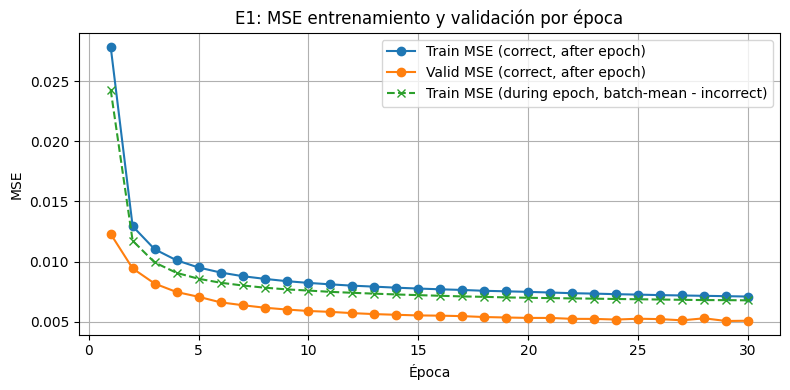

In [39]:
# Ploteo comparativo para E1: Train MSE (correct after epoch), Valid MSE (correct after epoch),
# y Train MSE (during epoch, batch-mean - incorrect) si están disponibles.

if 'results' in globals() and 'E1' in results and 'history' in results['E1']:
    hist = results['E1']['history']
    train_after = hist.get('train_mse', [])
    valid_after = hist.get('valid_mse', [])
    # intento obtener "train during" desde history; si no existe, uso la variable global train_avg_during si está
    train_during = hist.get('train_mse_during', None)
    if train_during is None and 'train_avg_during' in globals():
        train_during = train_avg_during

    if not train_after and not valid_after and not train_during:
        print("No hay curvas de MSE en history para 'E1'.")
    else:
        # determinar rango de épocas (usar el máximo disponible)
        max_len = max(len(train_after), len(valid_after), len(train_during) if train_during is not None else 0)
        epochs = range(1, max_len + 1)

        plt.figure(figsize=(8,4))
        if len(train_after):
            plt.plot(epochs[:len(train_after)], train_after, label='Train MSE (correct, after epoch)', marker='o')
        if len(valid_after):
            plt.plot(epochs[:len(valid_after)], valid_after, label='Valid MSE (correct, after epoch)', marker='o')
        if train_during is not None and len(train_during):
            plt.plot(epochs[:len(train_during)], train_during, label='Train MSE (during epoch, batch-mean - incorrect)', 
                     marker='x', linestyle='--')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E1: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de resultados para 'E1' en la variable results.")

### E2

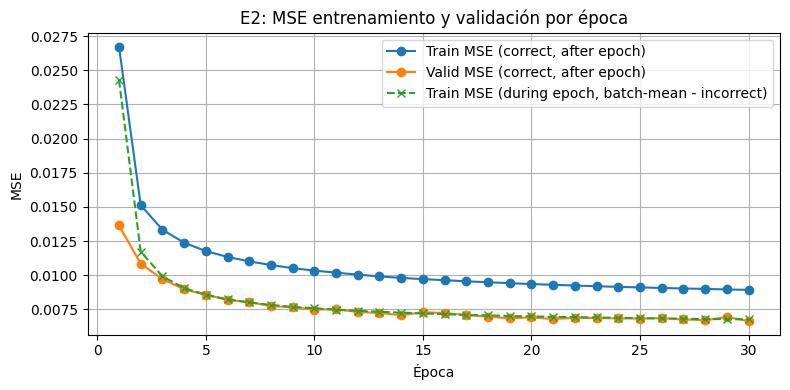

In [40]:
# y Train MSE (during epoch, batch-mean - incorrect) si están disponibles.

if 'results' in globals() and 'E2' in results and 'history' in results['E2']:
    hist = results['E2']['history']
    train_after = hist.get('train_mse', [])
    valid_after = hist.get('valid_mse', [])
    # Intento obtener "train during" desde history; si no existe, uso la variable global train_avg_during si está
    train_during = hist.get('train_mse_during', None)
    if train_during is None and 'train_avg_during' in globals():
        train_during = train_avg_during

    if not train_after and not valid_after and not train_during:
        print("No hay curvas de MSE en history para 'E2'.")
    else:
        max_len = max(len(train_after), len(valid_after), len(train_during) if train_during is not None else 0)
        epochs = range(1, max_len + 1)

        plt.figure(figsize=(8,4))
        if len(train_after):
            plt.plot(epochs[:len(train_after)], train_after, label='Train MSE (correct, after epoch)', marker='o')
        if len(valid_after):
            plt.plot(epochs[:len(valid_after)], valid_after, label='Valid MSE (correct, after epoch)', marker='o')
        if train_during is not None and len(train_during):
            plt.plot(epochs[:len(train_during)], train_during, label='Train MSE (during epoch, batch-mean - incorrect)', 
                     marker='x', linestyle='--')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E2: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de resultados para 'E2' en la variable results.")

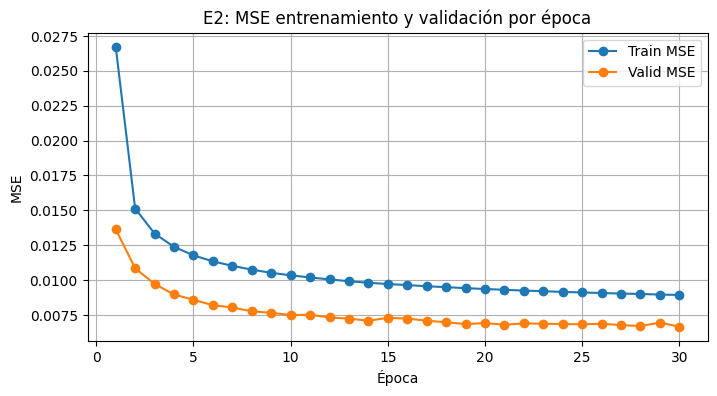

In [35]:
# Plot training and validation MSE per epoch for experiment E2
if 'results' in globals() and 'E2' in results and 'history' in results['E2']:
    hist = results['E2']['history']
    train_mse = hist.get('train_mse', [])
    valid_mse = hist.get('valid_mse', [])
    epochs = range(1, max(len(train_mse), len(valid_mse)) + 1)

    plt.figure(figsize=(8,4))
    if len(train_mse):
        plt.plot(epochs[:len(train_mse)], train_mse, label='Train MSE', marker='o')
    if len(valid_mse):
        plt.plot(epochs[:len(valid_mse)], valid_mse, label='Valid MSE', marker='o')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.title('E2: MSE entrenamiento y validación por época')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No hay datos de resultados para 'E2' en la variable results.")

### E3

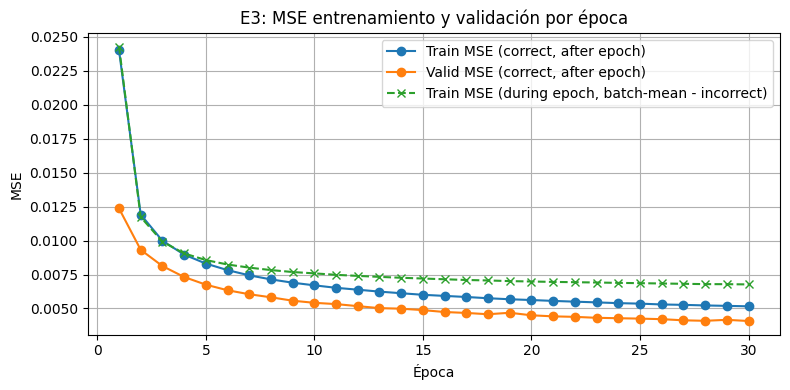

In [41]:
# y Train MSE (during epoch, batch-mean - incorrect) si están disponibles.

if 'results' in globals() and 'E3' in results and 'history' in results['E3']:
    hist = results['E3']['history']
    train_after = hist.get('train_mse', [])
    valid_after = hist.get('valid_mse', [])
    # Intento obtener "train during" desde history; si no existe, uso la variable global train_avg_during si está
    train_during = hist.get('train_mse_during', None)
    if train_during is None and 'train_avg_during' in globals():
        train_during = train_avg_during

    if not train_after and not valid_after and not train_during:
        print("No hay curvas de MSE en history para 'E3'.")
    else:
        max_len = max(len(train_after), len(valid_after), len(train_during) if train_during is not None else 0)
        epochs = range(1, max_len + 1)

        plt.figure(figsize=(8,4))
        if len(train_after):
            plt.plot(epochs[:len(train_after)], train_after, label='Train MSE (correct, after epoch)', marker='o')
        if len(valid_after):
            plt.plot(epochs[:len(valid_after)], valid_after, label='Valid MSE (correct, after epoch)', marker='o')
        if train_during is not None and len(train_during):
            plt.plot(epochs[:len(train_during)], train_during, label='Train MSE (during epoch, batch-mean - incorrect)', 
                     marker='x', linestyle='--')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E3: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de resultados para 'E3' en la variable results.")

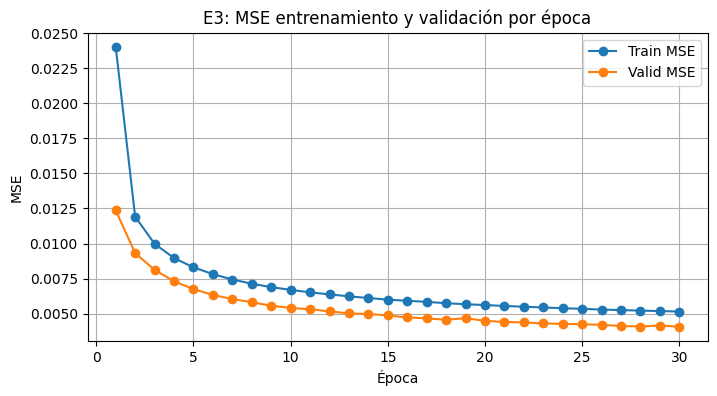

In [36]:
# Plot training and validation MSE per epoch for experiment E3
if 'results' in globals() and 'E3' in results and 'history' in results['E3']:
    hist = results['E3']['history']
    train_mse = hist.get('train_mse', [])
    valid_mse = hist.get('valid_mse', [])
    epochs = range(1, max(len(train_mse), len(valid_mse)) + 1)

    plt.figure(figsize=(8,4))
    if len(train_mse):
        plt.plot(epochs[:len(train_mse)], train_mse, label='Train MSE', marker='o')
    if len(valid_mse):
        plt.plot(epochs[:len(valid_mse)], valid_mse, label='Valid MSE', marker='o')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.title('E3: MSE entrenamiento y validación por época')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No hay datos de resultados para 'E3' en la variable results.")

### E4

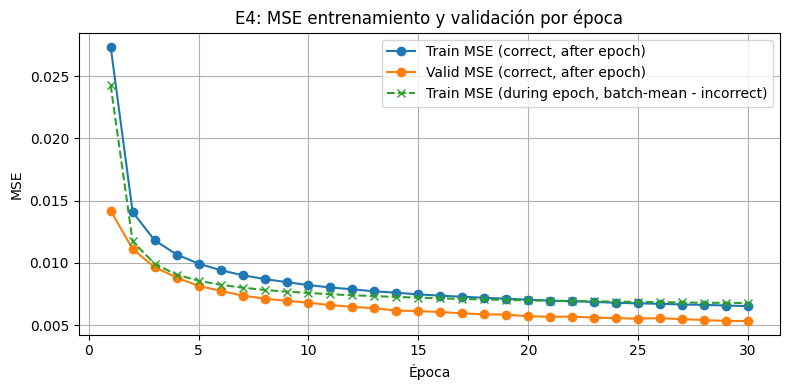

In [43]:
# y Train MSE (during epoch, batch-mean - incorrect) si están disponibles.

if 'results' in globals() and 'E4' in results and 'history' in results['E4']:
    hist = results['E4']['history']
    train_after = hist.get('train_mse', [])
    valid_after = hist.get('valid_mse', [])
    # Intento obtener "train during" desde history; si no existe, uso la variable global train_avg_during si está
    train_during = hist.get('train_mse_during', None)
    if train_during is None and 'train_avg_during' in globals():
        train_during = train_avg_during

    if not train_after and not valid_after and not train_during:
        print("No hay curvas de MSE en history para 'E4'.")
    else:
        max_len = max(len(train_after), len(valid_after), len(train_during) if train_during is not None else 0)
        epochs = range(1, max_len + 1)

        plt.figure(figsize=(8,4))
        if len(train_after):
            plt.plot(epochs[:len(train_after)], train_after, label='Train MSE (correct, after epoch)', marker='o')
        if len(valid_after):
            plt.plot(epochs[:len(valid_after)], valid_after, label='Valid MSE (correct, after epoch)', marker='o')
        if train_during is not None and len(train_during):
            plt.plot(epochs[:len(train_during)], train_during, label='Train MSE (during epoch, batch-mean - incorrect)', 
                     marker='x', linestyle='--')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E4: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de resultados para 'E4' en la variable results.")

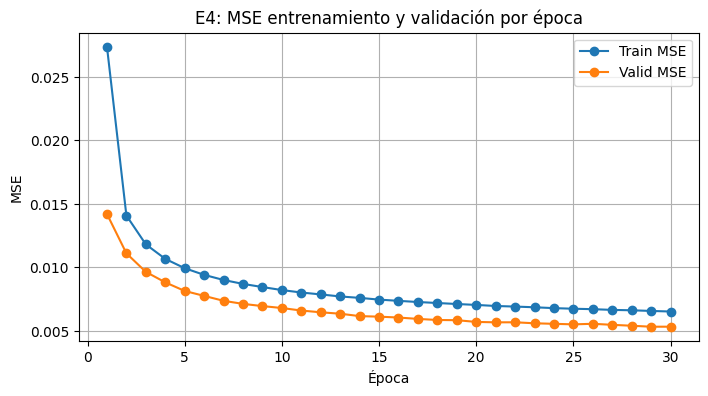

In [37]:
# Plot training and validation MSE per epoch for experiment E4
if 'results' in globals() and 'E4' in results and 'history' in results['E4']:
    hist = results['E4']['history']
    train_mse = hist.get('train_mse', [])
    valid_mse = hist.get('valid_mse', [])
    epochs = range(1, max(len(train_mse), len(valid_mse)) + 1)

    plt.figure(figsize=(8,4))
    if len(train_mse):
        plt.plot(epochs[:len(train_mse)], train_mse, label='Train MSE', marker='o')
    if len(valid_mse):
        plt.plot(epochs[:len(valid_mse)], valid_mse, label='Valid MSE', marker='o')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.title('E4: MSE entrenamiento y validación por época')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No hay datos de resultados para 'E4' en la variable results.")

### E5

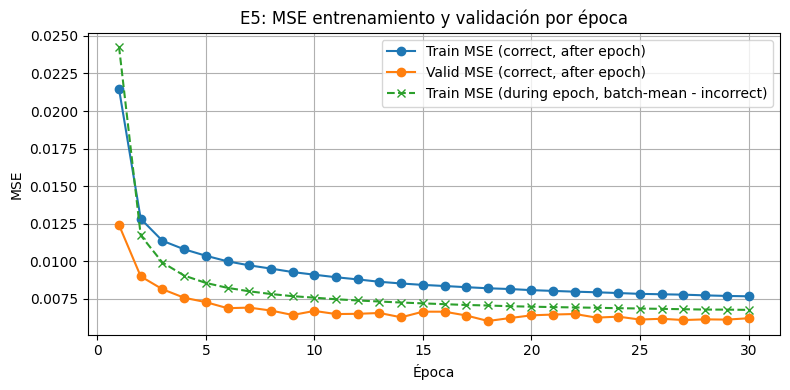

In [44]:
# y Train MSE (during epoch, batch-mean - incorrect) si están disponibles.

if 'results' in globals() and 'E5' in results and 'history' in results['E5']:
    hist = results['E5']['history']
    train_after = hist.get('train_mse', [])
    valid_after = hist.get('valid_mse', [])
    # Intento obtener "train during" desde history; si no existe, uso la variable global train_avg_during si está
    train_during = hist.get('train_mse_during', None)
    if train_during is None and 'train_avg_during' in globals():
        train_during = train_avg_during

    if not train_after and not valid_after and not train_during:
        print("No hay curvas de MSE en history para 'E5'.")
    else:
        max_len = max(len(train_after), len(valid_after), len(train_during) if train_during is not None else 0)
        epochs = range(1, max_len + 1)

        plt.figure(figsize=(8,4))
        if len(train_after):
            plt.plot(epochs[:len(train_after)], train_after, label='Train MSE (correct, after epoch)', marker='o')
        if len(valid_after):
            plt.plot(epochs[:len(valid_after)], valid_after, label='Valid MSE (correct, after epoch)', marker='o')
        if train_during is not None and len(train_during):
            plt.plot(epochs[:len(train_during)], train_during, label='Train MSE (during epoch, batch-mean - incorrect)', 
                     marker='x', linestyle='--')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E5: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de resultados para 'E5' en la variable results.")

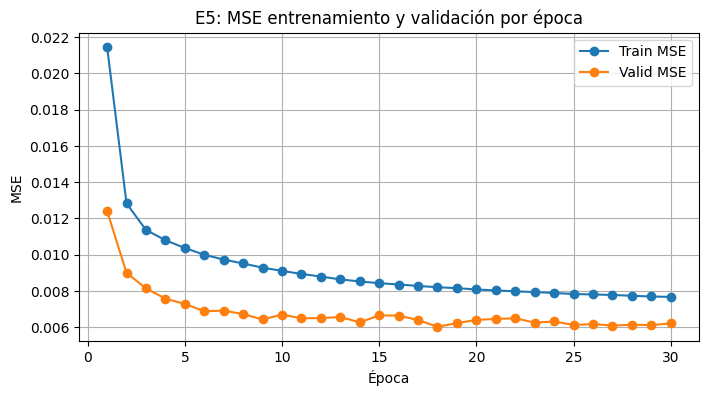

In [38]:
# Plot training and validation MSE per epoch for experiment E5
if 'results' in globals() and 'E5' in results and 'history' in results['E5']:
    hist = results['E5']['history']
    train_mse = hist.get('train_mse', [])
    valid_mse = hist.get('valid_mse', [])
    if not train_mse and not valid_mse:
        print("No hay curvas de MSE en history para 'E5'.")
    else:
        epochs = range(1, max(len(train_mse), len(valid_mse)) + 1)
        plt.figure(figsize=(8,4))
        if len(train_mse):
            plt.plot(epochs[:len(train_mse)], train_mse, label='Train MSE', marker='o')
        if len(valid_mse):
            plt.plot(epochs[:len(valid_mse)], valid_mse, label='Valid MSE', marker='o')
        plt.xlabel('Época')
        plt.ylabel('MSE')
        plt.title('E5: MSE entrenamiento y validación por época')
        plt.grid(True)
        plt.legend()
        plt.show()
else:
    print("No hay datos de resultados para 'E5' en la variable results.")

In [51]:
print("E1", results['E1']['history'])
print("E2", results['E2']['history'])
print("E3", results['E3']['history'])
print("E4", results['E4']['history'])
print("E5", results['E5']['history'])

E1 {'train_mse': [0.027870343130330245, 0.012934848212699095, 0.011022521273295085, 0.010099988536536694, 0.009502971520026524, 0.009086120143532753, 0.008782836836079756, 0.008559634927411875, 0.008368152321875095, 0.008222161512076855, 0.008100613282620907, 0.00799252085586389, 0.007911156237622102, 0.007824028551081816, 0.007753357165058454, 0.007689722427725792, 0.007636785468955834, 0.007565335373083751, 0.007522611497094234, 0.0074770298078656195, 0.007422377939522266, 0.0073671390307446325, 0.007332002607981364, 0.007284413809080919, 0.007248491575072209, 0.00720781127139926, 0.007177955112109582, 0.007148088073730469, 0.007119248911738396, 0.007089228976766268], 'valid_mse': [0.012294133263826371, 0.009426380856335162, 0.00816608975827694, 0.0074641381457448, 0.0070676894247531895, 0.0066066067263484, 0.006370658521354198, 0.00616147638708353, 0.006009783662855625, 0.005887509523332119, 0.005813979160785675, 0.005708941335976124, 0.005627995601296425, 0.0055713205680251125, 0.0

### Pre-entrenamiento con una red clasificadora convolucional profunda

Using encoder from results['E3'].
Encoder feature shape: (C=128, H=2, W=2)

--- Experiment: lr=0.001, dropout=0.5, fc=128 ---
Epoch  1 | train loss 0.5302 acc 0.8099 | valid loss 0.3878 acc 0.8583
Epoch  1 | train loss 0.5302 acc 0.8099 | valid loss 0.3878 acc 0.8583
Epoch  2 | train loss 0.3530 acc 0.8735 | valid loss 0.3295 acc 0.8794
Epoch  2 | train loss 0.3530 acc 0.8735 | valid loss 0.3295 acc 0.8794
Epoch  3 | train loss 0.3169 acc 0.8852 | valid loss 0.3207 acc 0.8849
Epoch  3 | train loss 0.3169 acc 0.8852 | valid loss 0.3207 acc 0.8849
Epoch  4 | train loss 0.2913 acc 0.8930 | valid loss 0.3087 acc 0.8879
Epoch  4 | train loss 0.2913 acc 0.8930 | valid loss 0.3087 acc 0.8879
Epoch  5 | train loss 0.2766 acc 0.8979 | valid loss 0.3028 acc 0.8909
Epoch  5 | train loss 0.2766 acc 0.8979 | valid loss 0.3028 acc 0.8909
Epoch  6 | train loss 0.2626 acc 0.9030 | valid loss 0.2898 acc 0.8955
Epoch  6 | train loss 0.2626 acc 0.9030 | valid loss 0.2898 acc 0.8955
Epoch  7 | train loss 

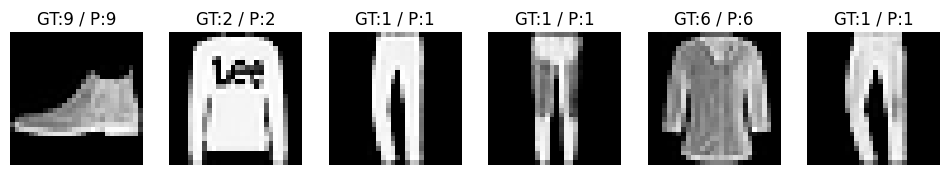

In [52]:
import torch
from torch import nn, optim
import numpy as np

# Fine-tune a deep conv classifier using the best pre-trained encoder (frozen).
# Uses existing objects in the notebook: `results`, `model` (fallback), `train_loader_clf`, `valid_loader_clf`, `device`.


# Select the best pretrained encoder (prefer results['E3'], fallback to `model.encoder`)
if 'results' in globals() and 'E3' in results and 'model' in results['E3']:
    pretrained_ae = results['E3']['model']
    encoder = pretrained_ae.encoder
    print("Using encoder from results['E3'].")
elif 'model' in globals() and hasattr(model, 'encoder'):
    encoder = model.encoder
    print("Using encoder from `model` variable.")
else:
    raise RuntimeError("No pretrained encoder found in workspace (expect results['E3']['model'] or model.encoder).")

# Freeze encoder parameters and set eval mode
for p in encoder.parameters():
    p.requires_grad = False
encoder.eval()

# Infer encoder output feature shape by running a batch through it
with torch.no_grad():
    xb_sample, _ = next(iter(train_loader_clf))
    xb_sample = xb_sample.to(device)
    feats = encoder(xb_sample)
feat_ch = feats.size(1)
feat_h, feat_w = feats.size(2), feats.size(3)
print(f"Encoder feature shape: (C={feat_ch}, H={feat_h}, W={feat_w})")

# Classifier head: small conv-stack -> global pooling -> MLP -> LogSoftmax
class ClassifierHead(nn.Module):
    def __init__(self, in_channels, num_classes=10, dropout=0.5, fc_hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, in_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                           # reduce spatial dims
            nn.Conv2d(in_channels*2, in_channels*4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1)),               # (B, C, 1, 1)
            nn.Flatten(),                              # (B, C)
            nn.Dropout(dropout),
            nn.Linear(in_channels*4, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(fc_hidden, num_classes),
            nn.LogSoftmax(dim=1)
        )
    def forward(self, x):
        return self.net(x)

# Wrapper: encoder (frozen) + classifier head (trainable)
class FullClassifier(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head
    def forward(self, x):
        # encoder is frozen; run without grad for safety
        with torch.no_grad():
            feats = self.encoder(x)
        return self.head(feats)

# Training / eval utilities (NLLLoss with LogSoftmax output)
def train_one_epoch(dataloader, model, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

def eval_epoch(dataloader, model, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            running_loss += loss.item() * xb.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total

# Experiment grid (small). Adjust epochs as needed.
experiment_grid = [
    {"lr": 1e-3,  "dropout": 0.5, "fc_hidden": 128, "opt": "adam", "epochs": 10},
    {"lr": 5e-4,  "dropout": 0.3, "fc_hidden": 128, "opt": "adam", "epochs": 10},
    {"lr": 1e-3,  "dropout": 0.5, "fc_hidden": 64,  "opt": "adam", "epochs": 10},
]

results_clf = {}

for cfg in experiment_grid:
    print(f"\n--- Experiment: lr={cfg['lr']}, dropout={cfg['dropout']}, fc={cfg['fc_hidden']} ---")
    head = ClassifierHead(in_channels=feat_ch, num_classes=num_classes, dropout=cfg['dropout'], fc_hidden=cfg['fc_hidden']).to(device)
    clf = FullClassifier(encoder, head).to(device)
    # Optimizer: only head parameters (encoder frozen)
    params = filter(lambda p: p.requires_grad, clf.parameters())
    if cfg["opt"].lower() == "adam":
        optimizer = optim.Adam(params, lr=cfg["lr"])
    else:
        optimizer = optim.SGD(params, lr=cfg["lr"], momentum=0.9)
    criterion = nn.NLLLoss()
    history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}
    best_val_acc = 0.0
    best_epoch = -1

    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc = train_one_epoch(train_loader_clf, clf, optimizer, criterion, device)
        val_loss, val_acc = eval_epoch(valid_loader_clf, clf, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["valid_loss"].append(val_loss)
        history["valid_acc"].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
        print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | valid loss {val_loss:.4f} acc {val_acc:.4f}")

    print(f"Best val acc {best_val_acc:.4f} at epoch {best_epoch}")
    results_clf[f"lr{cfg['lr']}_do{cfg['dropout']}_fc{cfg['fc_hidden']}"] = {
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "model": clf
    }

# After experiments: print summary sorted by best validation accuracy
summary = sorted(
    [(k, v["best_val_acc"], v["best_epoch"]) for k, v in results_clf.items()],
    key=lambda x: x[1], reverse=True
)
print("\nSummary (sorted by val acc):")
for name, acc, epoch in summary:
    print(f"{name}: val_acc={acc:.4f} at epoch {epoch}")

# Visual check: some validation images and predicted labels from the best model
best_model_key = summary[0][0]
best_clf_model = results_clf[best_model_key]["model"]
best_clf_model.eval()
xb_vis, yb_vis = next(iter(valid_loader_clf))
n_vis = min(6, xb_vis.size(0))
xb_vis = xb_vis[:n_vis].to(device)
with torch.no_grad():
    out_vis = best_clf_model(xb_vis)
preds_vis = out_vis.argmax(dim=1).cpu().numpy()
xb_disp_vis = ((xb_vis.cpu().squeeze(1) + 1.0) / 2.0).numpy()
fig, axes = plt.subplots(1, n_vis, figsize=(2*n_vis,2))
for i in range(n_vis):
    axes[i].imshow(xb_disp_vis[i], cmap='Greys_r')
    axes[i].set_title(f"GT:{int(yb_vis[i])} / P:{int(preds_vis[i])}")
    axes[i].axis('off')
plt.show()
# Visual comparison of untrained ConvAutoencoder reconstructions    
class ConvAutoencoder(nn.Module):
    def __init__(self, p=0.2, latent_dim=128):
        super().__init__()
        # Encoder (conv -> relu -> maxpool -> dropout)
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16,
                      kernel_size=3, stride=1, padding=1),   # -> (16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                              # -> (16,14,14)
            nn.Conv2d(in_channels=16, out_channels=16,
                      kernel_size=3, stride=1, padding=1),   # -> (16,14,14)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                              # -> (16,7,7)
            nn.Dropout(p=p)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16*7*7, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 16*7*7)
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(16,7,7))
        self.relu = nn.ReLU()
        # Decoder (convtranspose -> relu -> dropout)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=16, out_channels=16,
                               kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (16,14,14)
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.ConvTranspose2d(in_channels=16, out_channels=1,
                               kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (1,28,28)
            nn.Sigmoid()  # output in [0,1]
        )

In [59]:
print(results_clf)

{'lr0.001_do0.5_fc128': {'history': {'train_loss': [0.5301646262904008, 0.35300657774011296, 0.3169322401036819, 0.29129603332529463, 0.2765580062071482, 0.26263041569540896, 0.24972659690926471, 0.23944606848061084, 0.23039419493327537, 0.22012107039491335], 'train_acc': [0.8099, 0.8734666666666666, 0.8852333333333333, 0.8929833333333334, 0.8978666666666667, 0.9029666666666667, 0.9089666666666667, 0.9108333333333334, 0.91345, 0.9186333333333333], 'valid_loss': [0.3878447397053242, 0.32954986780881884, 0.32073231220245363, 0.3087302768230438, 0.30281799271702764, 0.28980316787958144, 0.3093511798977852, 0.29951367154717445, 0.319202256500721, 0.2851744060218334], 'valid_acc': [0.8583, 0.8794, 0.8849, 0.8879, 0.8909, 0.8955, 0.8917, 0.895, 0.89, 0.9001]}, 'best_val_acc': 0.9001, 'best_epoch': 10, 'model': FullClassifier(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.05, inplace=False)
 

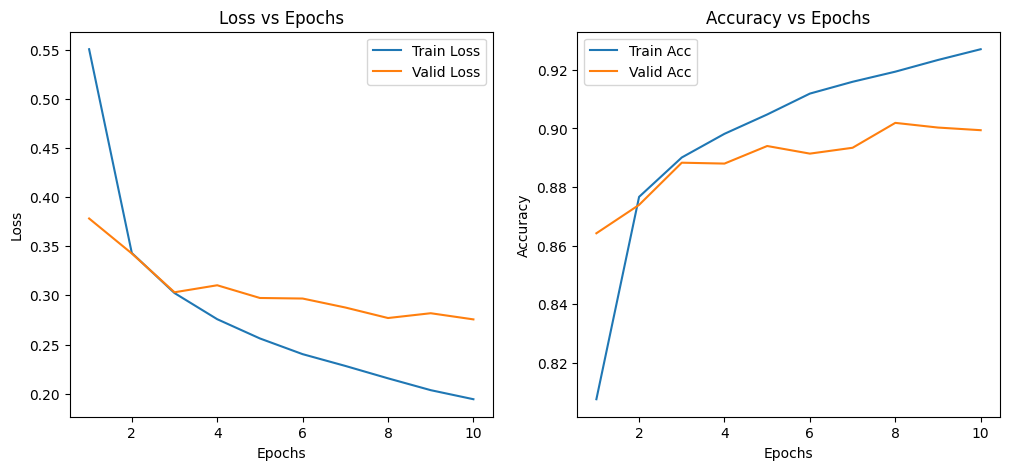

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar el historial del mejor modelo
best_model_key = summary[0][0]
history = results_clf[best_model_key]["history"]

epochs = range(1, len(history["train_loss"]) + 1)

# Gráfico de pérdidas
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["valid_loss"], label="Valid Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Gráfico de precisión
plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["valid_acc"], label="Valid Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()


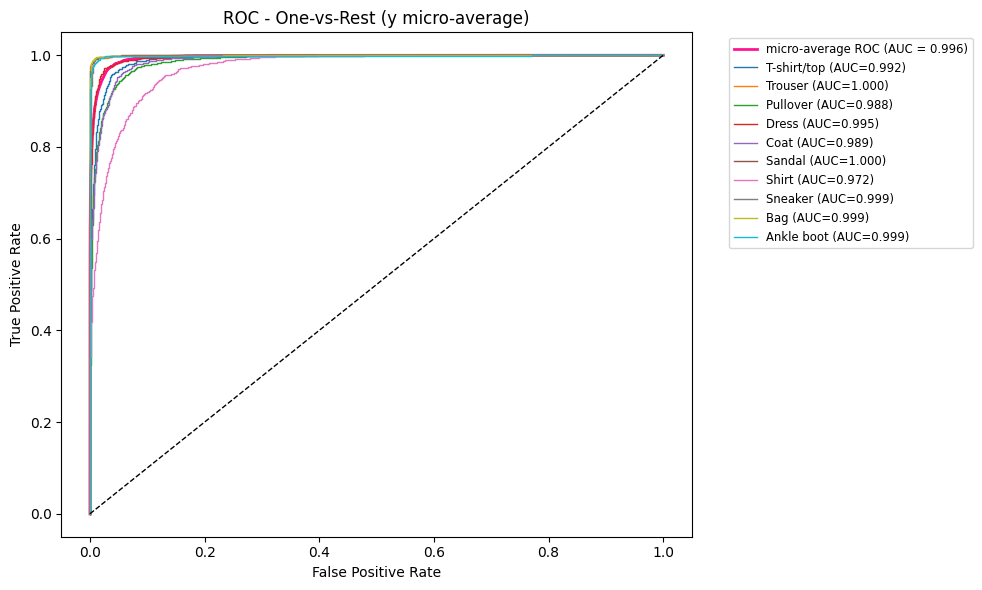

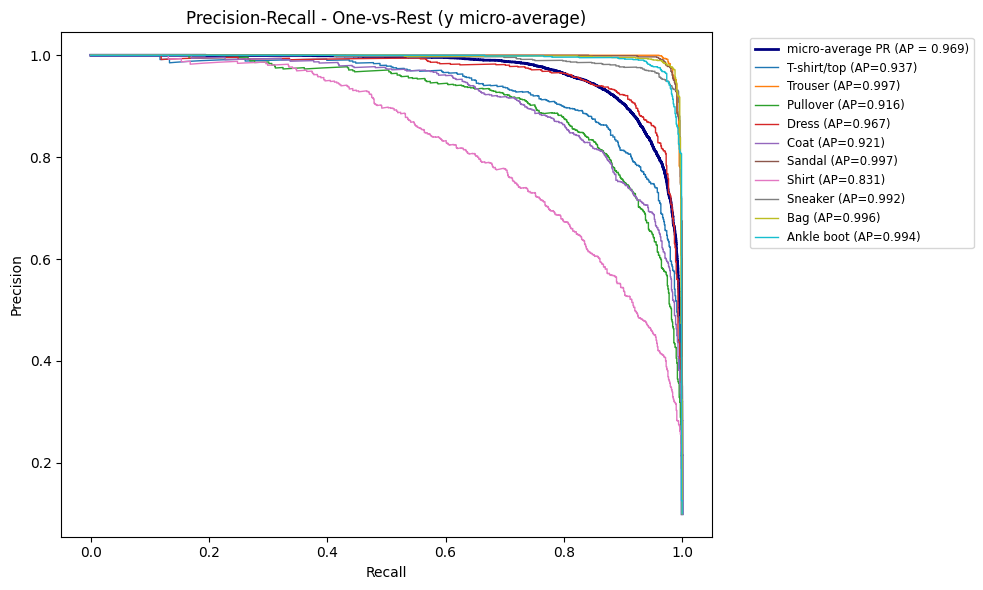

In [57]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ROC / AUC y Precision-Recall (multiclase, one-vs-rest + micro-avg)
import matplotlib.pyplot as plt

# Recolectar etiquetas verdaderas y probabilidades predichas (exp(LogSoftmax) -> probs)
best_clf_model.eval()
y_true_list = []
y_score_list = []
with torch.no_grad():
    for xb, yb in valid_loader_clf:
        xb = xb.to(device)
        out = best_clf_model(xb)            # salida LogSoftmax
        probs = torch.exp(out).cpu().numpy()
        y_score_list.append(probs)
        y_true_list.append(yb.numpy())

y_score = np.vstack(y_score_list)                   # (N, n_classes)
y_true = np.concatenate(y_true_list)                # (N,)
n_classes = y_score.shape[1]

# binarizar etiquetas
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# nombres de etiquetas
label_names = getattr(train_set_orig, "classes", [str(i) for i in range(n_classes)])

# ROC por clase + micro-average
fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average ROC (AUC = {roc_auc['micro']:.3f})", color='deeppink', lw=2)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=1, label=f"{label_names[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - One-vs-Rest (y micro-average)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

# Precision-Recall por clase + micro-average
precision = dict(); recall = dict(); ap = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap[i] = average_precision_score(y_true_bin[:, i], y_score[:, i])
# micro
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), y_score.ravel())
ap["micro"] = average_precision_score(y_true_bin, y_score, average="micro")

plt.figure(figsize=(10,6))
plt.plot(recall["micro"], precision["micro"], label=f"micro-average PR (AP = {ap['micro']:.3f})", color='navy', lw=2)
for i in range(n_classes):
    plt.plot(recall[i], precision[i], lw=1, label=f"{label_names[i]} (AP={ap[i]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall - One-vs-Rest (y micro-average)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

### Matriz de consufion

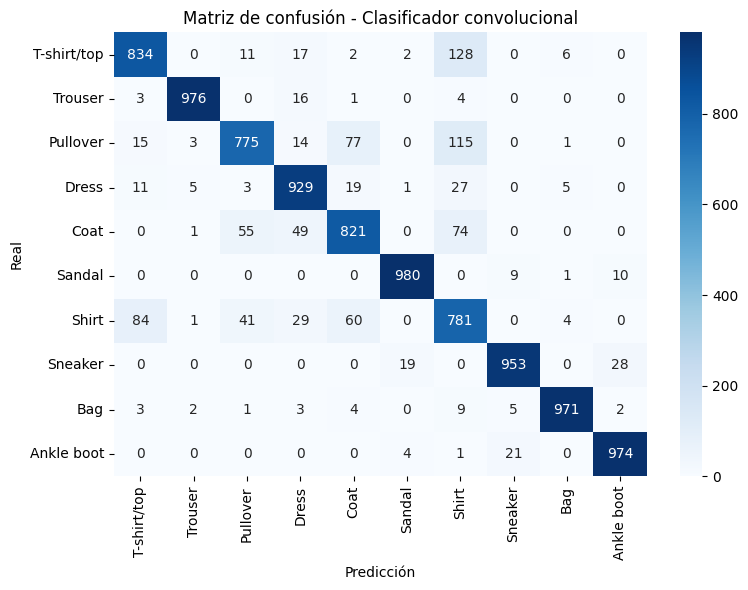

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# y_true contiene las etiquetas verdaderas, y_score contiene las probabilidades predichas
# Para la matriz de confusión, necesitamos las predicciones finales (clase de mayor probabilidad)
y_pred = y_score.argmax(axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Nombres de las clases (si están disponibles)
if 'label_names' in globals():
    classes = label_names
else:
    classes = [str(i) for i in range(cm.shape[0])]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - Clasificador convolucional')
plt.tight_layout()
plt.show()